# Exploratory Data Analysis

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Smart Pathing to find the data
current_dir = os.getcwd()
if current_dir.endswith('notebooks'):
    project_root = os.path.dirname(current_dir)
else:
    project_root = current_dir

data_path = os.path.join(project_root, 'data', 'raw', 'synthetic_mobility_data.csv')
print(f"Loading data from: {data_path}")

Loading data from: C:\Users\Eric\Desktop\Mobility-Demand-Forecaster\data\raw\synthetic_mobility_data.csv


In [3]:
# Load and prep dates
df = pd.read_csv(data_path)

print(f"Dataset Shape: {df.shape}")
df.head(3)

Dataset Shape: (14705, 16)


,ResNo,AccountCode,PickupDateTimeScheduled,DropoffDateTimeActual,PrefferedVehicleType,Pickup_State,EventCategory,Revenue,InternalDriverCost,AffiliateCost,TotalCost,GrossProfit,ServiceType,EstDriverHours,EstOverheadCost,RevenueStatus
0,100001,23462,Jan 01 2024 05:48AM,Jan 01 2024 06:34AM,SEDN,PA,89862,151.11,41.86,0.00,58.14,92.97,In-House,1.3,16.28,Actual
1,100002,46738,Jan 01 2024 03:17PM,Jan 01 2024 04:00PM,SUV,PA,89862,243.19,0.00,57.46,78.61,164.58,Affiliate,1.2,21.15,Actual
2,100003,19633,Jan 01 2024 04:44PM,Jan 01 2024 05:42PM,SUV,SC,89862,263.05,0.00,52.10,83.20,179.85,Affiliate,1.5,31.10,Actual


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14705 entries, 0 to 14704
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ResNo                    14705 non-null  int64  
 1   AccountCode              14705 non-null  int64  
 2   PickupDateTimeScheduled  14705 non-null  object 
 3   DropoffDateTimeActual    14705 non-null  object 
 4   PrefferedVehicleType     14705 non-null  object 
 5   Pickup_State             14705 non-null  object 
 6   EventCategory            14705 non-null  object 
 7   Revenue                  14705 non-null  float64
 8   InternalDriverCost       14705 non-null  float64
 9   AffiliateCost            14705 non-null  float64
 10  TotalCost                14705 non-null  float64
 11  GrossProfit              14705 non-null  float64
 12  ServiceType              14705 non-null  object 
 13  EstDriverHours           14705 non-null  float64
 14  EstOverheadCost       

In [6]:
# Explicitly define the date format
date_format = '%b %d %Y %I:%M%p'

df['PickupDateTimeScheduled'] = pd.to_datetime(df['PickupDateTimeScheduled'], format=date_format)
df['DropoffDateTimeActual'] = pd.to_datetime(df['DropoffDateTimeActual'], format=date_format)

# Feature Engineering: Extracting highly predictive time components
df['Date'] = df['PickupDateTimeScheduled'].dt.date
df['DayOfWeek'] = df['PickupDateTimeScheduled'].dt.day_name()
df['PickupHour'] = df['PickupDateTimeScheduled'].dt.hour
df['TripDurationMinutes'] = (df['DropoffDateTimeActual'] - df['PickupDateTimeScheduled']).dt.total_seconds() / 60

print(f"Dataset Shape: {df.shape}")
print("\nVerified Data Types:")
print(df[['PickupDateTimeScheduled', 'DropoffDateTimeActual', 'PickupHour']].dtypes)
df.head(3)

Dataset Shape: (14705, 20)

Verified Data Types:
PickupDateTimeScheduled    datetime64[ns]
DropoffDateTimeActual      datetime64[ns]
PickupHour                          int32
dtype: object


,ResNo,AccountCode,PickupDateTimeScheduled,DropoffDateTimeActual,PrefferedVehicleType,Pickup_State,EventCategory,Revenue,InternalDriverCost,AffiliateCost,TotalCost,GrossProfit,ServiceType,EstDriverHours,EstOverheadCost,RevenueStatus,Date,DayOfWeek,PickupHour,TripDurationMinutes
0,100001,23462,2024-01-01 05:48:00,2024-01-01 06:34:00,SEDN,PA,89862,151.11,41.86,0.00,58.14,92.97,In-House,1.3,16.28,Actual,2024-01-01,Monday,5,46.0
1,100002,46738,2024-01-01 15:17:00,2024-01-01 16:00:00,SUV,PA,89862,243.19,0.00,57.46,78.61,164.58,Affiliate,1.2,21.15,Actual,2024-01-01,Monday,15,43.0
2,100003,19633,2024-01-01 16:44:00,2024-01-01 17:42:00,SUV,SC,89862,263.05,0.00,52.10,83.20,179.85,Affiliate,1.5,31.10,Actual,2024-01-01,Monday,16,58.0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14705 entries, 0 to 14704
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   ResNo                    14705 non-null  int64         
 1   AccountCode              14705 non-null  int64         
 2   PickupDateTimeScheduled  14705 non-null  datetime64[ns]
 3   DropoffDateTimeActual    14705 non-null  datetime64[ns]
 4   PrefferedVehicleType     14705 non-null  object        
 5   Pickup_State             14705 non-null  object        
 6   EventCategory            14705 non-null  object        
 7   Revenue                  14705 non-null  float64       
 8   InternalDriverCost       14705 non-null  float64       
 9   AffiliateCost            14705 non-null  float64       
 10  TotalCost                14705 non-null  float64       
 11  GrossProfit              14705 non-null  float64       
 12  ServiceType              14705 n

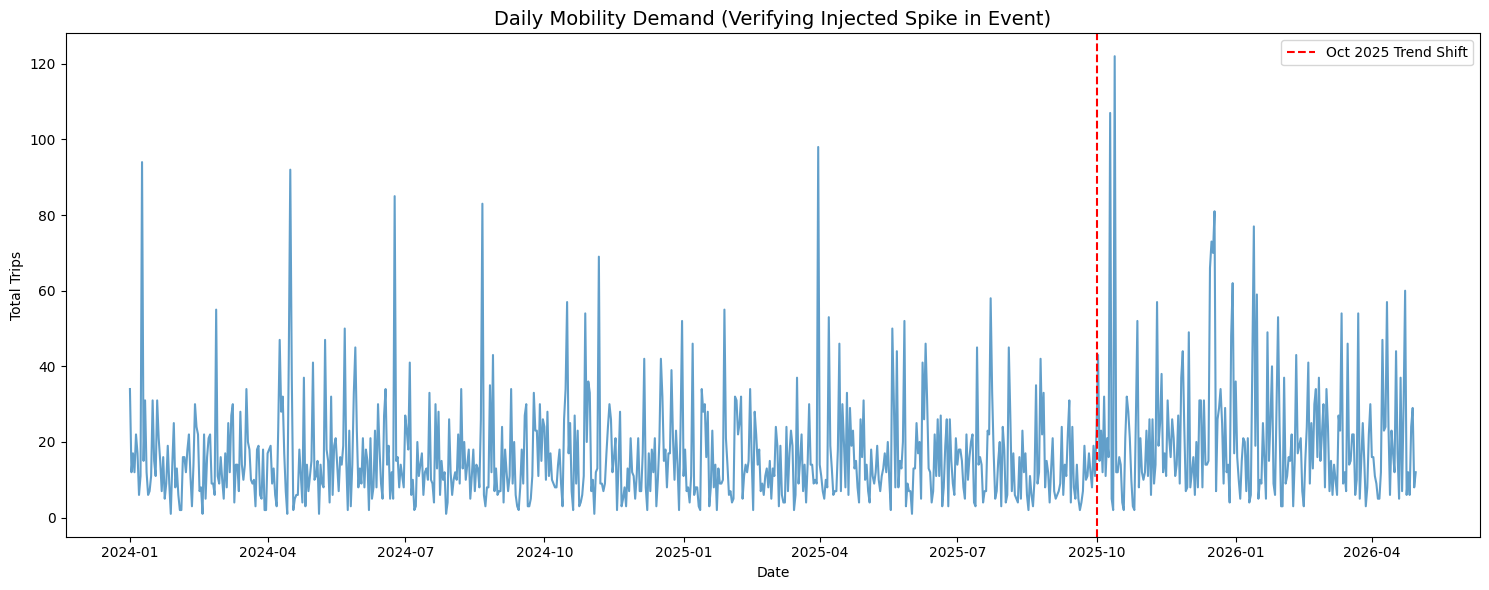

In [10]:
# Aggregate daily trip volume
daily_volume = df.groupby('Date').size().reset_index(name='TripCount')
daily_volume['Date'] = pd.to_datetime(daily_volume['Date'])

plt.figure(figsize=(15, 6))
sns.lineplot(data=daily_volume, x='Date', y='TripCount', alpha=0.7)

# Add a vertical line for our injected shift
plt.axvline(pd.to_datetime('2025-10-01'), color='red', linestyle='--', label='Oct 2025 Trend Shift')

plt.title('Daily Mobility Demand (Verifying Injected Spike in Event)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Total Trips')
plt.legend()
plt.tight_layout()
plt.show()

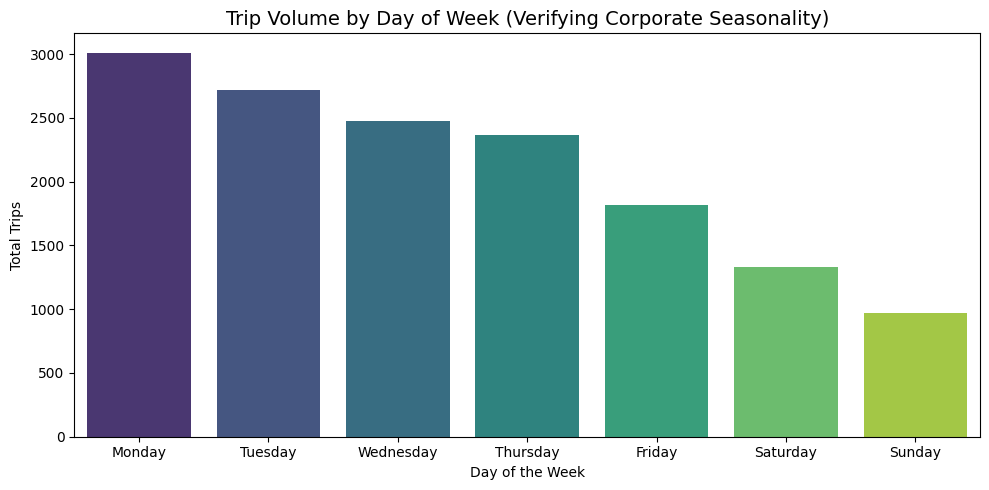

In [21]:
# Order the days logically
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(10, 5))
sns.countplot(
    data=df, 
    x='DayOfWeek', 
    hue='DayOfWeek',   
    legend=False,      
    order=day_order, 
    palette='viridis'
)

plt.title('Trip Volume by Day of Week (Verifying Corporate Seasonality)', fontsize=14)
plt.xlabel('Day of the Week')
plt.ylabel('Total Trips')
plt.tight_layout()
plt.show()

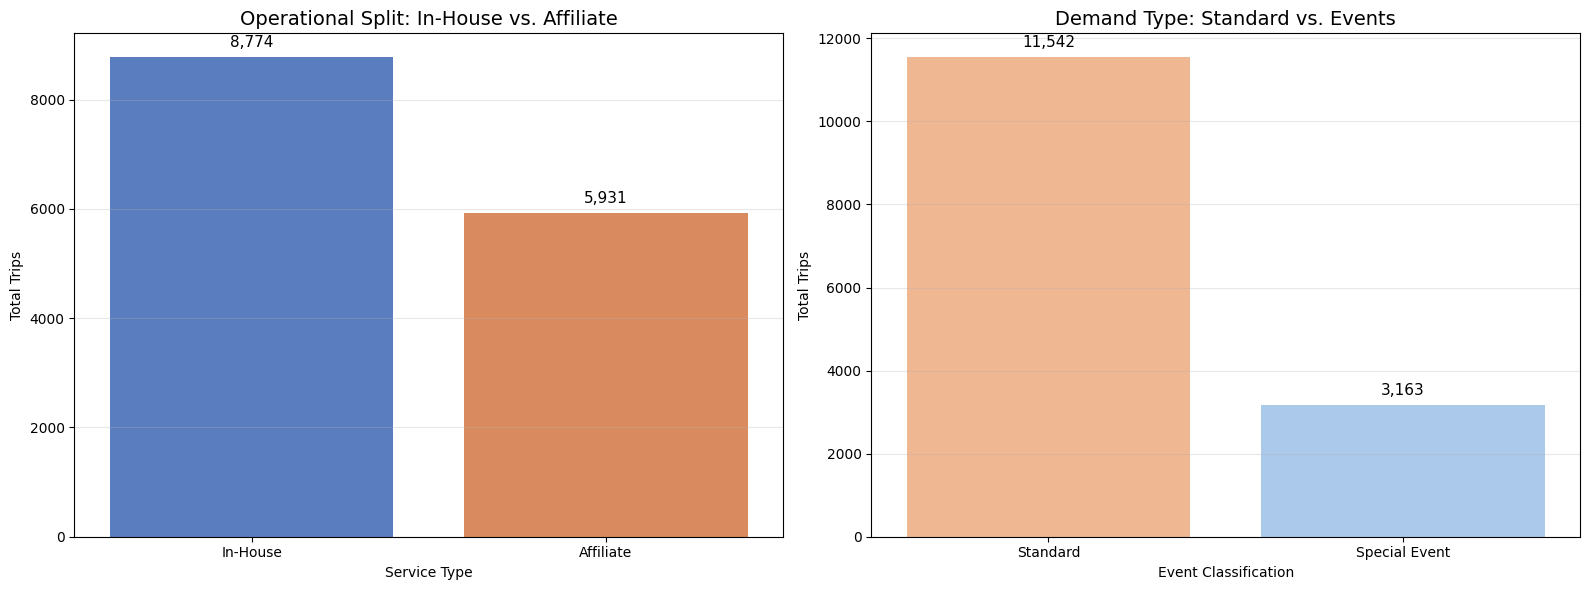

In [20]:
# Create a temporary binary flag for clean visualization
df['IsEvent'] = df['EventCategory'].apply(lambda x: 'Standard' if x == 'Standard' else 'Special Event')

# Set up a side-by-side dashboard
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Service Type (In-House vs Affiliate)
sns.countplot(
    data=df, 
    x='ServiceType', 
    hue='ServiceType',
    legend=False,
    palette='muted', 
    ax=axes[0],
    order=['In-House', 'Affiliate']
)
axes[0].set_title('Operational Split: In-House vs. Affiliate', fontsize=14)
axes[0].set_xlabel('Service Type')
axes[0].set_ylabel('Total Trips')
axes[0].grid(axis='y', alpha=0.3)

# Add value labels to the bars
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}', 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=11, xytext=(0, 5), 
                     textcoords='offset points')


# Event vs Standard
sns.countplot(
    data=df, 
    x='IsEvent', 
    hue='IsEvent',
    legend=False,
    palette='pastel', 
    ax=axes[1],
    order=['Standard', 'Special Event']
)
axes[1].set_title('Demand Type: Standard vs. Events', fontsize=14)
axes[1].set_xlabel('Event Classification')
axes[1].set_ylabel('Total Trips')
axes[1].grid(axis='y', alpha=0.3)

# Add value labels to the bars
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height()):,}', 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=11, xytext=(0, 5), 
                     textcoords='offset points')

plt.tight_layout()
plt.show()

Aggregated Dataset Shape: (168, 3)

Sample of our New Target Variable:
  MonthStart PrefferedVehicleType  TotalTrips
0 2024-01-01                   MC           8
1 2024-01-01             MID-MINI          15
2 2024-01-01                 MINI          44
3 2024-01-01                 SEDN         244
4 2024-01-01                  SUV         184


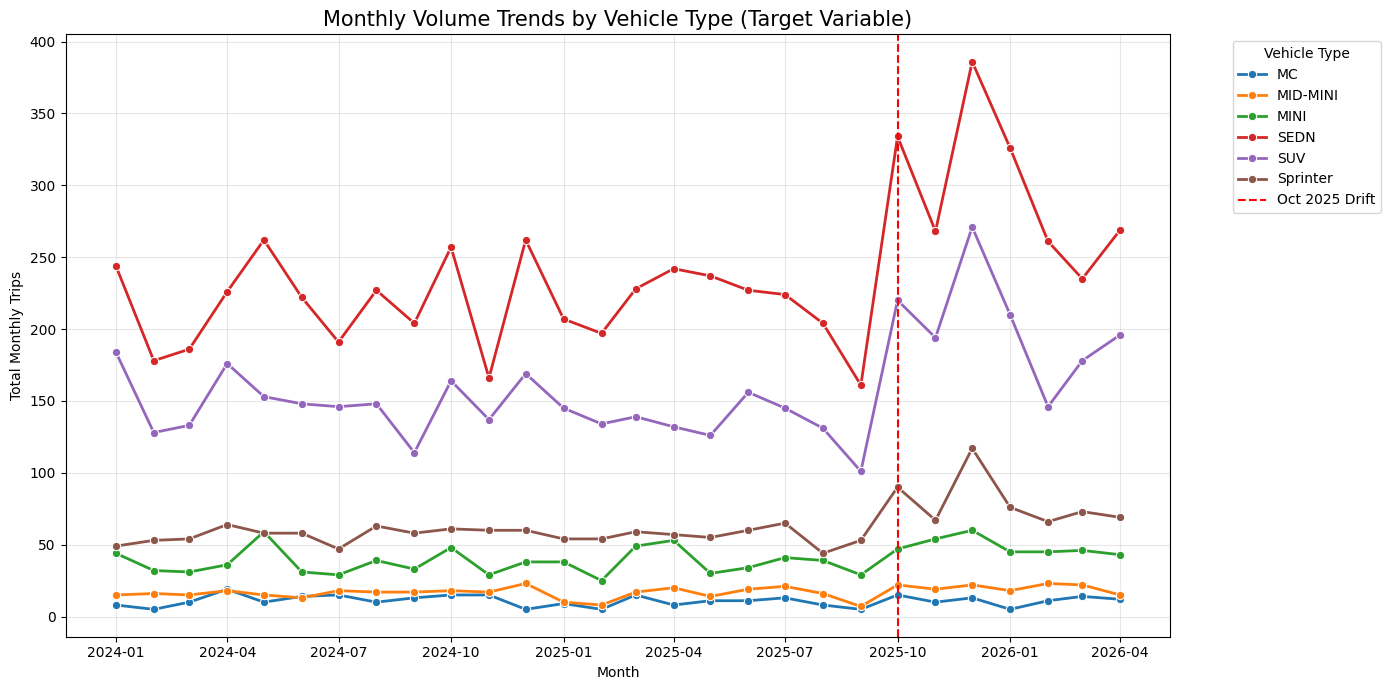

In [14]:
# Create a Month-Start feature for time-series grouping
df['MonthStart'] = df['PickupDateTimeScheduled'].dt.to_period('M').dt.to_timestamp()

# Aggregate into Monthly Volume per Vehicle Type
monthly_demand = df.groupby(['MonthStart', 'PrefferedVehicleType']).size().reset_index(name='TotalTrips')

print(f"Aggregated Dataset Shape: {monthly_demand.shape}")
print("\nSample of our New Target Variable:")
print(monthly_demand.head())

# Visualize the Monthly Trend
plt.figure(figsize=(14, 7))
sns.lineplot(
    data=monthly_demand, 
    x='MonthStart', 
    y='TotalTrips', 
    hue='PrefferedVehicleType', 
    marker='o',
    linewidth=2
)

# Add October 2025 shift line for context
plt.axvline(pd.to_datetime('2025-10-01'), color='red', linestyle='--', label='Oct 2025 Drift')

plt.title('Monthly Volume Trends by Vehicle Type (Target Variable)', fontsize=15)
plt.xlabel('Month')
plt.ylabel('Total Monthly Trips')
plt.legend(title='Vehicle Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()